In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
gapfill_df = pd.read_csv('../../4_figure_MPN_metrics/output/MPN_all_gapfill_df.csv', index_col=0)
gapfill_df['HGVSc'] = gapfill_df['HGVSc'].fillna('unassigned')

/tmp/ipykernel_380208/546937070.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  gapfill_df = pd.read_csv('../../4_figure_MPN_metrics/output/MPN_all_gapfill_df.csv', index_col=0)


In [3]:
wt_gapfills = gapfill_df.loc[(gapfill_df['HGVSc'].str.contains('wildtype')) | ((gapfill_df['gapfill'] == gapfill_df['gapfill_from_transcriptome']))]
n_wt = wt_gapfills['count_of_this_gapfill'].sum()

unexpected_mutations = gapfill_df.drop(wt_gapfills.index).loc[(gapfill_df['expected_frequency_from_bulk'].isna())]
unexpected_mutations = unexpected_mutations.loc[unexpected_mutations['count_of_this_gapfill'] > 0]
n_unexpected = unexpected_mutations['count_of_this_gapfill'].sum()

expected_mutations = gapfill_df.drop(wt_gapfills.index).loc[(gapfill_df['expected_frequency_from_bulk'].notna())]
n_expected = expected_mutations['count_of_this_gapfill'].sum()

/tmp/ipykernel_380208/586506234.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


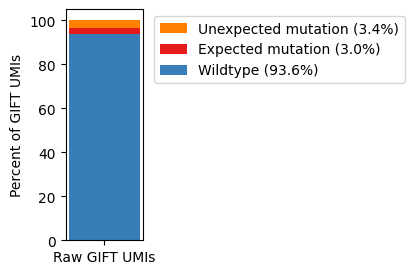

In [4]:
total = n_wt + n_expected + n_unexpected

fig, ax = plt.subplots(figsize=(1, 3))

bottom = 0
for val, color, label in zip(
    [n_wt / total, n_expected / total, n_unexpected / total],
    ['#377eb8', '#e41a1c', '#ff7f00'],
    ['Wildtype', 'Expected mutation', 'Unexpected mutation']
):
    ax.bar(0, val * 100, 0.6, bottom=bottom * 100, color=color, label=f'{label} ({val:.1%})')
    bottom += val

ax.set_xticks([0])
ax.set_xticklabels(['Raw GIFT UMIs'])
ax.set_ylabel('Percent of GIFT UMIs')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('../plots/variant_discovery_metrics.pdf')

38344
2988


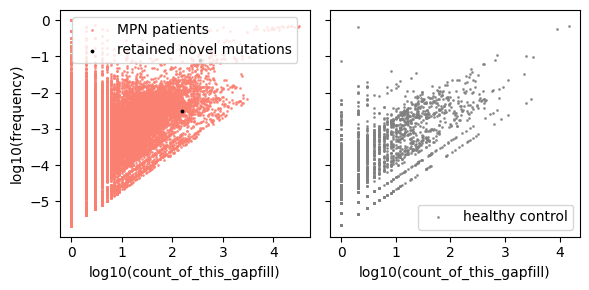

In [5]:
x = np.log10(unexpected_mutations['count_of_this_gapfill'])
y  = np.log10(unexpected_mutations['frequency'])

fig,(ax,ax2) = plt.subplots(1,2,figsize=(6,3), sharey=True)
ax.scatter(x,y, s=1, color='salmon', alpha=0.8, label = 'MPN patients')
print(len(x))

x = np.log10(unexpected_mutations.loc[(unexpected_mutations['HGVSc'] == 'NRAS c.35G>A') & (unexpected_mutations['sample'] == 'BC007_1')]['count_of_this_gapfill'])
y = np.log10(unexpected_mutations.loc[(unexpected_mutations['HGVSc'] == 'NRAS c.35G>A') & (unexpected_mutations['sample'] == 'BC007_1')]['frequency'])
ax.scatter(x,y, s=3, color='k', alpha=1)

x = np.log10(unexpected_mutations.loc[(unexpected_mutations['HGVSc'] == 'ASXL1 c.4183C>G') & (unexpected_mutations['sample'] == 'BC003_1')]['count_of_this_gapfill'])
y = np.log10(unexpected_mutations.loc[(unexpected_mutations['HGVSc'] == 'ASXL1 c.4183C>G') & (unexpected_mutations['sample'] == 'BC003_1')]['frequency'])
ax.scatter(x,y, s=3, color='k', alpha=1, label = 'retained novel mutations')

x_control = np.log10(unexpected_mutations.loc[unexpected_mutations['sample'].isin(['BC016_1','BC015_2'])]['count_of_this_gapfill'])
y_control = np.log10(unexpected_mutations.loc[unexpected_mutations['sample'].isin(['BC016_1','BC015_2'])]['frequency'])
ax2.scatter(x_control,y_control, s=1, color='grey', label='healthy control', alpha=0.8)
print(len(x_control))

ax.set_xlabel('log10(count_of_this_gapfill)')
ax.set_ylabel('log10(frequency)')
ax2.set_xlabel('log10(count_of_this_gapfill)')

ax.legend()
ax2.legend()
plt.tight_layout()

plt.savefig('../plots/unexpected_mutations_scatter.pdf')

In [6]:
variants = ['TP53 c.72dup_novel', 'TET2 c.2908dupA','NRAS c.35G>A','ASXL1 c.4183C>G', 'PPM1D c.1636dup', 'PPM1D c.1639del']

included_samples = gapfill_df.loc[gapfill_df['HGVSc'].isin(variants)]['sample'].value_counts()
included_samples = included_samples.loc[included_samples == len(variants)].index.tolist()

sample_order = ['BC016_1','BC015_2']

for variant in variants:
    sample_order.extend(gapfill_df.loc[(gapfill_df['HGVSc'] == variant) & (gapfill_df['sample'].isin(included_samples)) & (gapfill_df['expected_frequency_from_bulk'] > 0)]['sample'].drop_duplicates().tolist())

sample_order = list(dict.fromkeys(sample_order))

sample_order = sample_order + [s for s in included_samples if s not in sample_order] 



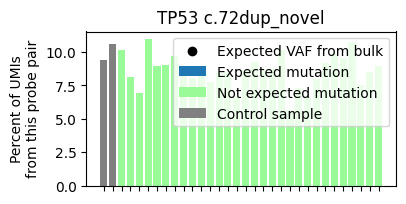

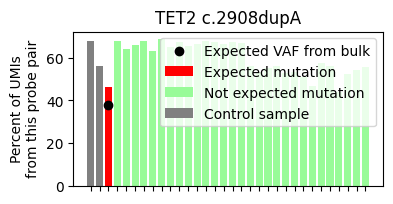

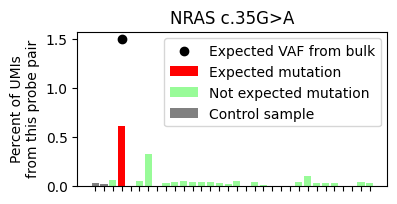

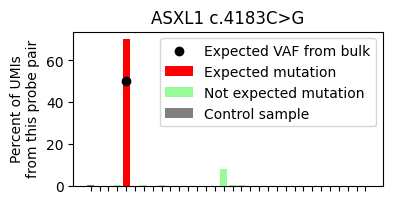

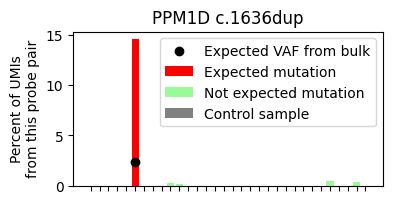

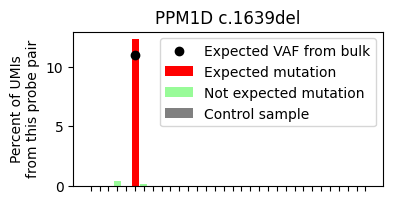

In [7]:
for variant in ['TP53 c.72dup_novel', 'TET2 c.2908dupA','NRAS c.35G>A','ASXL1 c.4183C>G','PPM1D c.1636dup', 'PPM1D c.1639del']:
    sub_df = gapfill_df.loc[gapfill_df['HGVSc'] == variant][['HGVSc','sample','frequency','count_of_this_probe','expected_frequency_from_bulk']].sort_values('frequency', ascending=False)
    sub_df = sub_df.loc[sub_df['count_of_this_probe'] > 0].copy()

    sub_df = sub_df.loc[sub_df['sample'].isin(sample_order)].copy()
    sub_df['sample'] = pd.Categorical(sub_df['sample'], categories=sample_order, ordered=True)
    sub_df = sub_df.sort_values('sample')

    sub_df['color'] = sub_df.apply(lambda row: 'grey' if row['sample'] in ['BC016_1','BC015_2'] else ('red' if pd.notna(row['expected_frequency_from_bulk']) else 'palegreen'), axis=1)

    fig,ax = plt.subplots(figsize=(4,2))

    ax.bar(sub_df['sample'], sub_df['frequency'] * 100, color=sub_df['color'])

    df = sub_df.loc[sub_df['expected_frequency_from_bulk'].notna()].copy()
    ax.bar(df['sample'], df['frequency'] * 100, color=df['color'], label='Expected mutation')
    ax.scatter(df['sample'], df['expected_frequency_from_bulk'] * 100, color='black', label='Expected VAF from bulk')

    df = sub_df.loc[~sub_df['sample'].isin(['BC016_1','BC015_2']) & sub_df['expected_frequency_from_bulk'].isna()].copy()
    ax.bar(df['sample'], df['frequency'] * 100, color=df['color'], label='Not expected mutation')

    df = sub_df.loc[sub_df['sample'].isin(['BC016_1','BC015_2'])].copy()
    ax.bar(df['sample'], df['frequency'] * 100, color=df['color'], label='Control sample')

    ax.set_xlabel('')
    ax.tick_params(axis='x', which='both', labelbottom=False)
    ax.set_ylabel('Percent of UMIs\nfrom this probe pair')
    ax.set_title(variant)
    ax.legend()

    plt.savefig('../plots/mutated_percent_by_sample_{}.pdf'.format(variant.replace(' ','_').replace('.','_').replace('>','_').replace('(','_').replace(')','_')))